# Lab 2b: Model selection
## Dark matter
We'll use the MAGIC telescope dataset (http://www.openml.org/d/1120). The task is to classifying gamma rays, which consist of high-energy particles. When they hit our atmosphere, they produce chain reactions of other particles called 'showers'. However, similar showers are also produced by other particles (hadrons). We want to be able to detect which ones originate from gamma rays and which ones come from background radiation. To do this, the observed shower patterns are observed and converted into 10 numeric features. You need to detect whether these are gamma rays or background radiation. This is a key aspect of research into dark matter, which is believed to generate such gamma rays. If we can detect where they occur, we can build a map of the origins of gamma radiation, and locate where dark matter may occur in the observed universe. However, we'll first need to accurately detect these gamma rays first.

A quick visualization of the features is shown below. Note that this is not a time series, we just plot the instances in the order they occur in the dataset. The first 12500 or so are examples of signal (gamma), the final 6700 or so are background (hadrons).

In [1]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
from matplotlib import cm

In [2]:
# Download MAGIC Telescope data from OpenML. You can repeat this analysis with any other OpenML classification dataset.
magic = oml.datasets.get_dataset(1120)
X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array'); 
attribute_names = [f.name for i,f in magic.features.items()][:-1][1:]

C:\Users\20182672\AppData\Local\Temp\ipykernel_16232\2616928666.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');


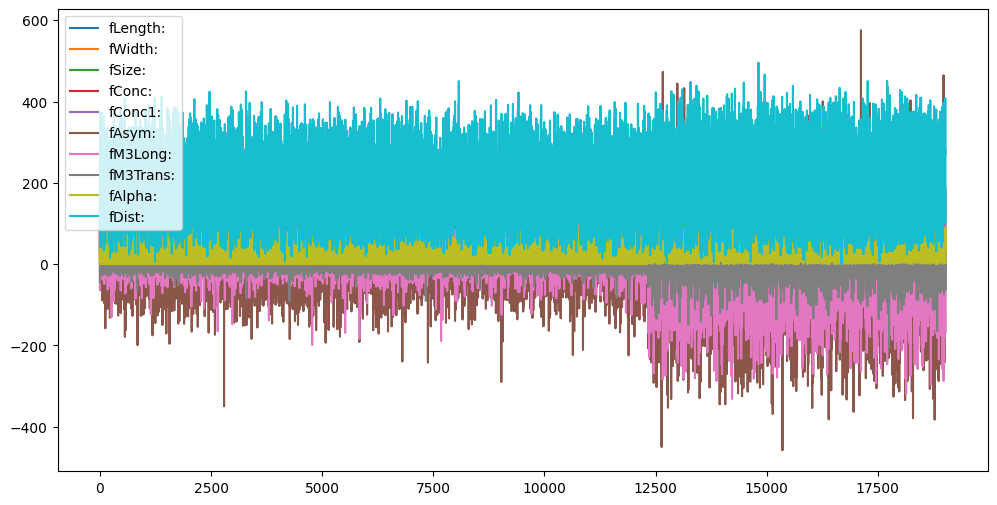

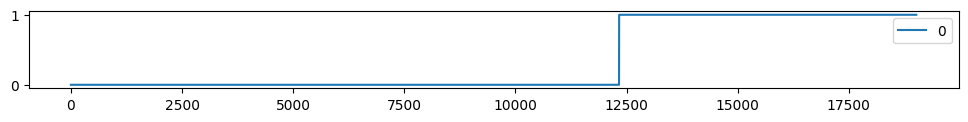

In [3]:
# Quick visualization of the features (top) and the target (bottom)
magic_df = pd.DataFrame(X, columns=attribute_names)
magic_df.plot(figsize=(12,6))
# Also plot the target: 1 = background, 0 = gamma
pd.DataFrame(y).plot(figsize=(12,1));

## Exercise 1: Metrics
Train and evaluate an SVM with RBF kernel (default hyperparameters) using a standard 25% holdout. Report the accuracy, precision, recall, F1 score, and area under the ROC curve (AUC).

Answer the following questions:
* How many of the detected gamma rays are actually real gamma rays?
* How many of all the gamma rays are we detecting?
* How many false positives and false negatives occur?

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Hold-out default 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

# Train a SVM with RBF kernel
clf = SVC(kernel='rbf').fit(X_train, y_train)

In [5]:
# Predict and evaluate
y_pred = clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print("confusion_matrix(y_test, y_pred): \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, clf.decision_function(X_test)))


Accuracy: 0.8243953732912723
confusion_matrix(y_test, y_pred): 
 [[2948  135]
 [ 700  972]]
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      3083
           1       0.88      0.58      0.70      1672

    accuracy                           0.82      4755
   macro avg       0.84      0.77      0.79      4755
weighted avg       0.83      0.82      0.81      4755

AUC: 0.8709373598387204


## Exercise 2: Preprocessing
SVMs require scaling to perform well. For now, use the following code to scale the data (we'll get back to this in the lab about preprocessing and pipelines). Repeat question 2 on the scaled data. Have the results improved? 

In [6]:
from sklearn.preprocessing import StandardScaler
# Important here is to fit the scaler on the training data alone
# Then, use it to scale both the training set and test set
# This assumes that you named your training set X_train. Adapt if needed.
scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test = scaler.transform(X_test)

In [7]:
# Train a SVM with RBF kernel on scaled data
clf = SVC(kernel='rbf').fit(Xs_train, y_train)

# Predict and evaluate
y_pred = clf.predict(Xs_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print("confusion_matrix(y_test, y_pred): \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, clf.decision_function(Xs_test)))

Accuracy: 0.8717139852786541
confusion_matrix(y_test, y_pred): 
 [[2956  127]
 [ 483 1189]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      3083
           1       0.90      0.71      0.80      1672

    accuracy                           0.87      4755
   macro avg       0.88      0.83      0.85      4755
weighted avg       0.88      0.87      0.87      4755

AUC: 0.9213932865366021


## Exercise 3: Hyperparameter optimization
Use 50 iterations of random search to tune the $C$ and $gamma$ hyperparameters on the scaled training data. Vary both on a log scale (e.g. from 2^-12 to 2^12). Optimize on AUC and use 3 cross-validation (CV) folds for the inner CV to estimate performance. For the outer loop, just use the train-test split you used before (hence, no nested CV). Report the best hyperparameters and the corresponding AUC score. Is it better than the default? Finally, use them to evaluate the model on the held-out test set, for all 5 metrics we used before.

Extra challenge: plot the samples used by the random search ($C$ vs $gamma$)

Note: The reason we don't use a nested CV just yet is because we would need to rebuild the scaled training and test set multiple times. This is tedious, unless we use pipelines, which we'll cover in a future lab.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid to serach for C and game on log-scale from 2^-12 to 2^12
param_grid = {'C': np.logspace(-12, 12, num=25, base=2),
                       'gamma': np.logspace(-12, 12, num=25, base=2)}
# Random search for 50 iterations with 3-fold cross-validation optimized for AUC
random_search = RandomizedSearchCV(SVC(kernel='rbf'), param_distributions=param_grid, n_iter=50, n_jobs= -1, cv=3, random_state=0)
random_search.fit(Xs_train, y_train)

# Retrieve the AUC score and the best parameters
print('Best AUC:', random_search.best_score_)
print('Best parameters:', random_search.best_params_)

Best AUC: 0.8700315457413249
Best parameters: {'gamma': 0.03125, 'C': 2048.0}


Accuracy: 0.8824395373291273
confusion_matrix(y_test, y_pred): 
 [[2965  118]
 [ 441 1231]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      3083
           1       0.91      0.74      0.81      1672

    accuracy                           0.88      4755
   macro avg       0.89      0.85      0.86      4755
weighted avg       0.89      0.88      0.88      4755

AUC: 0.9310656757927017


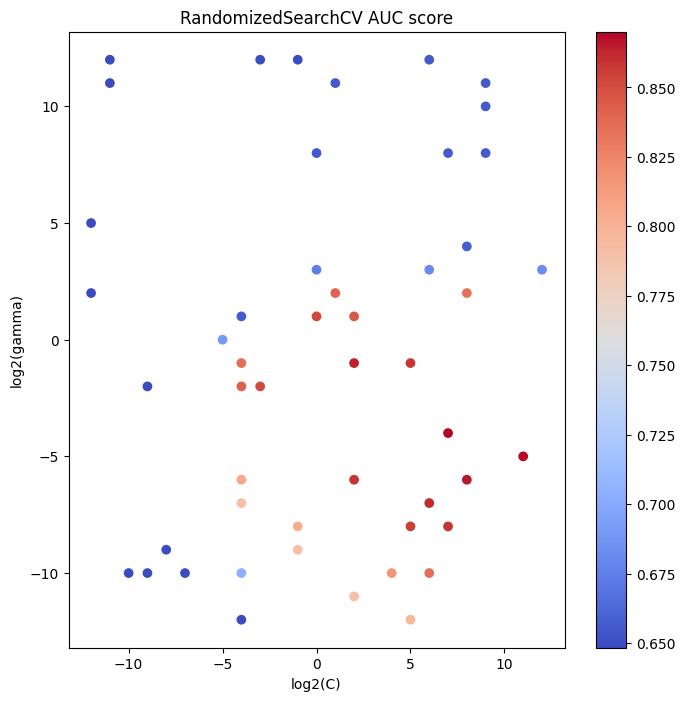

In [9]:
best_clf = random_search.best_estimator_
# Test model on hold out data
y_pred = best_clf.predict(Xs_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print("confusion_matrix(y_test, y_pred): \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, best_clf.decision_function(Xs_test)))

# Plot the samples used by RandomizedSearchCV so C versus gamma
plt.figure(figsize=(8,8))
plt.scatter(np.log2(random_search.cv_results_['param_C'].data), np.log2(random_search.cv_results_['param_gamma'].data), c=random_search.cv_results_['mean_test_score'], cmap=cm.coolwarm)
plt.colorbar()
plt.xlabel('log2(C)')
plt.ylabel('log2(gamma)')
plt.title('RandomizedSearchCV AUC score')
plt.show()


## Exercise 4: Threshold calibration
First, plot the Precision-Recall curve for the SVM using the default parameters on the scaled data. Then, calibrate the threshold to find a solution that yields better recall without sacrificing too much precision.

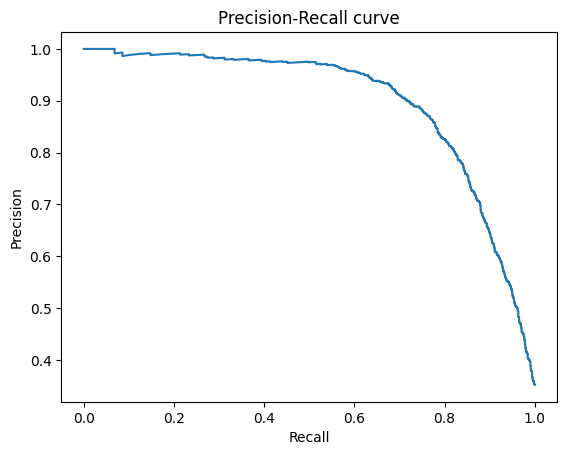

In [10]:
# Plot the Precision-Recall curve for the SVM on Xs_test with default parameters of SVM
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, clf.decision_function(Xs_test))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()

In [11]:
# Calibrate threshold in precision-recall curve

# Print the values of the precision and recall for threshold equals to 0
# Find index of threshold closest to zero
zero_index = np.argmin(np.abs(thresholds))
print('Precision:', precision[zero_index])
print('Recall:', recall[zero_index])

# Find candidate indices where recall is higher AND precision is at least as high as original
valid_indices = np.where((recall > recall[zero_index]) & (precision >= precision[zero_index]))[0]

if len(valid_indices) > 0:
    # Select the threshold corresponding to the highest recall among valid indices
    best_index = valid_indices[np.argmax(recall[valid_indices])]
    best_threshold = thresholds[best_index]

    # Print the values for the new threshold
    print('New Precision:', precision[best_index])
    print('New Recall:', recall[best_index])
    print('Optimal Threshold:', best_threshold)
else:
    print('No threshold found that improves recall while maintaining precision.')


Precision: 0.9035687167805618
Recall: 0.7117224880382775
No threshold found that improves recall while maintaining precision.


## Exercise 5: Cost function
Assume that a false negative is twice as bad (costly) than a false positive. I.e. we would rather waste time checking gamma ray sources that are not real, than missing an interesting gamma ray source. Use ROC analysis to find the optimal threshold under this assumption.

Finally, let the model make predictions using the optimal threshold and report all 5 scores. Is recall better now? Did we lose a lot of precision?

Optimal Threshold: -1.1745771512898942
False Positive Rate at Optimal Threshold: 0.3480
True Positive Rate (Recall) at Optimal Threshold: 0.9258


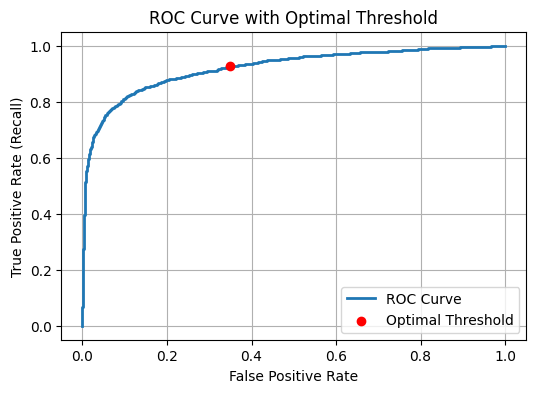

In [12]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, clf.decision_function(Xs_test))

# Define the cost function where FN is twice as costly as FP
def cost_function(fpr, tpr, cost_FN=2, cost_FP=1, ratio_P=None):
    if ratio_P is None:
        ratio_P = np.mean(y_test)  # P(Y=1) estimate
    return fpr * cost_FP * ratio_P + (1 - tpr) * (1 - ratio_P) * cost_FN

# Compute costs for all thresholds
costs = cost_function(fpr, tpr)

# Find the optimal threshold (minimum cost)
optimal_index = np.argmin(costs)
optimal_threshold = thresholds[optimal_index]

# Print results
print(f"Optimal Threshold: {optimal_threshold}")
print(f"False Positive Rate at Optimal Threshold: {fpr[optimal_index]:.4f}")
print(f"True Positive Rate (Recall) at Optimal Threshold: {tpr[optimal_index]:.4f}")

# Plot the ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve", lw=2)
plt.scatter(fpr[optimal_index], tpr[optimal_index], color='red', label="Optimal Threshold", zorder=3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Optimal Threshold")
plt.legend()
plt.grid()
plt.show()


In [13]:
# Make prediction with roc_curve using the optimal threshold
y_pred = clf.decision_function(Xs_test) > optimal_threshold
print('Accuracy:', accuracy_score(y_test, y_pred))
print("confusion_matrix(y_test, y_pred): \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, clf.decision_function(Xs_test)))

Accuracy: 0.7480546792849632
confusion_matrix(y_test, y_pred): 
 [[2010 1073]
 [ 125 1547]]
              precision    recall  f1-score   support

           0       0.94      0.65      0.77      3083
           1       0.59      0.93      0.72      1672

    accuracy                           0.75      4755
   macro avg       0.77      0.79      0.75      4755
weighted avg       0.82      0.75      0.75      4755

AUC: 0.9213932865366021
